# CNN+Transformer 직관 노트북 — Guijarro-Ordonez, Pelger, Zanotti (2025)

논문 Figure 14–19의 해석(interpretability) 분석을 **한국 replication 데이터**로 재현한다.
저자 공식 노트북 `Deep_Learning_Statistical_Arbitrage_Code/notebooks/signal-visualization.ipynb`가
미국 IPCA5 잔차와 저자 체크포인트를 요구하는 것과 달리, 이 노트북은 이 저장소에 이미 있는
한국 PCA5 잔차와 로컬 학습 체크포인트만 사용하므로 그대로 실행된다.

**실행**

```bash
uv run jupyter lab guijarro-ordonez-2025-replication/notebooks/cnn-transformer-intuition.ipynb
```

CPU로 수 분 내에 끝난다. 필요한 입력은 두 개다.

| 입력 | 경로 |
|---|---|
| 학습된 정책 체크포인트 | `outputs/strategies/pca5_cnn_transformer_sharpe_lb30_e100_rolling_no-cost/checkpoints/subperiod_00.pt` |
| PCA5 잔차 패널 | `outputs/pca/daily_residuals_k5_20200102_c252_l60.parquet` |

**주의.** 여기 나오는 모든 그림은 한국 표본(잔차 2020-01-02~2026-07-20, 정책 OOS 2024-01-19~)에서
얻은 것이다. 원 논문의 미국 1998–2016 결과와 **수치가 같을 이유가 없다**. 이 노트북의 목적은
논문 수치 재현이 아니라 *모델 내부를 어떻게 열어보는가*를 익히는 것이다.

## 목차

| 절 | 내용 | 대응 |
|---|---|---|
| §0 | 준비 | — |
| §1 | 왜 CNN인가: 파라미터 수와 weight sharing | 본문 2.4절 논거 |
| §2 | 인과성(causality) 확인 — 미래를 보지 않는가 | look-ahead 점검 |
| §3 | CNN이 배운 국소 기본 패턴 | Figure 15 |
| §4 | 실제 잔차 창 하나의 내부 | Figure 17 |
| §5 | 사인파 probe — attention과 주기성 | Figure 16 |
| §6 | NAAG — 30일 중 어느 날이 중요한가 | Figure 19 |
| §7 | 상승/하락 비대칭성 | 본문 Introduction 주장 |
| §8 | 잔차 가격 대 배분 가중치 | Figure 14 |

## §0 준비

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

# 저장소 어디에서 실행하든 replication 루트를 찾는다
_here = Path.cwd().resolve()
PROJECT = next(
    (p for p in [_here, *_here.parents] if (p / "src" / "guijarro_ordonez_replication").is_dir()),
    None,
)
if PROJECT is None:
    raise SystemExit("guijarro-ordonez-2025-replication 루트를 찾지 못했습니다.")
sys.path.insert(0, str(PROJECT / "src"))

from guijarro_ordonez_replication.interpretability import (  # noqa: E402
    cnn_states,
    load_cnn_checkpoint,
    _local_patterns,
)
from guijarro_ordonez_replication.trading import (  # noqa: E402
    cumulative_windows,
    load_pca_residual_panel,
)

LOOKBACK = 30
SEED = 0
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})
print("torch", torch.__version__, "| PROJECT:", PROJECT.name)

torch 2.13.0+cpu | PROJECT: guijarro-ordonez-2025-replication


In [2]:
CHECKPOINT = (
    PROJECT / "outputs" / "strategies"
    / "pca5_cnn_transformer_sharpe_lb30_e100_rolling_no-cost"
    / "checkpoints" / "subperiod_00.pt"
)
PCA_ROOT = PROJECT / "outputs" / "pca"

model = load_cnn_checkpoint(CHECKPOINT, lookback=LOOKBACK)
panel = load_pca_residual_panel(
    PCA_ROOT / "daily_residuals_k5_20200102_c252_l60.parquet",
    PCA_ROOT / "daily_low_rank_loadings_k5_20200102_c252_l60.parquet",
)
windows, selected = cumulative_windows(panel.residuals, panel.observed, LOOKBACK)

print(f"잔차 패널  : {panel.residuals.shape[0]}일 x {panel.residuals.shape[1]}종목")
print(f"표본 기간  : {panel.dates[0].date()} ~ {panel.dates[-1].date()}")
print(f"학습 창    : {windows.shape}  (창 개수, 종목, lookback)")
print(f"유효 창 수 : {selected.sum():,}")

잔차 패널  : 1606일 x 228종목
표본 기간  : 2020-01-02 ~ 2026-07-20
학습 창    : (1576, 228, 30)  (창 개수, 종목, lookback)
유효 창 수 : 267,011


`cumulative_windows`가 하는 일을 짚고 가자. 모델 입력은 **잔차 수익률이 아니라 누적 잔차**다.

```python
windows[i, n] = np.cumsum(residuals[day-30:day, n])   # day = 30 + i
```

즉 잔차를 로그가격처럼 누적한 **"잔차 가격" 경로**를 본다. 그래야 "떨어졌다가 돌아온다"는
평균회귀 모양이 눈에 보이는 형태가 된다. 그리고 창의 마지막 원소는 `day-1`까지만 포함하므로
**당일 거래되는 수익률은 입력에 들어가지 않는다** — look-ahead 방지다.

## §1 왜 CNN인가 — 파라미터 수와 weight sharing

### 1-1. 파라미터를 세어보자

In [3]:
print(f"{'parameter':<40}{'shape':>16}{'count':>8}")
print("-" * 64)
for name, p in model.named_parameters():
    print(f"{name:<40}{str(tuple(p.shape)):>16}{p.numel():>8}")
total_cnn = sum(p.numel() for p in model.parameters())
print("-" * 64)
print(f"{'CNN+Transformer 합계':<40}{'':>16}{total_cnn:>8}")

# 같은 일을 하는 평범한 완전연결망
ffn = nn.Sequential(
    nn.Linear(LOOKBACK, 64), nn.ReLU(),
    nn.Linear(64, 64), nn.ReLU(),
    nn.Linear(64, 1),
)
total_ffn = sum(p.numel() for p in ffn.parameters())
print(f"\n동급 FFN(30-64-64-1) 파라미터 : {total_ffn:,}")
print(f"배율                          : {total_ffn / total_cnn:.1f}x")

parameter                                          shape   count
----------------------------------------------------------------
blocks.0.conv1.weight                          (8, 1, 2)      16
blocks.0.conv1.bias                                 (8,)       8
blocks.0.conv2.weight                          (8, 8, 2)     128
blocks.0.conv2.bias                                 (8,)       8
encoder.self_attn.in_proj_weight                 (24, 8)     192
encoder.self_attn.in_proj_bias                     (24,)      24
encoder.self_attn.out_proj.weight                 (8, 8)      64
encoder.self_attn.out_proj.bias                     (8,)       8
encoder.linear1.weight                           (16, 8)     128
encoder.linear1.bias                               (16,)      16
encoder.linear2.weight                           (8, 16)     128
encoder.linear2.bias                                (8,)       8
encoder.norm1.weight                                (8,)       8
encoder.norm1.bias       

CNN 부분만 보면 더 극적이다. `conv1`은 `(8, 1, 2)` = **16개**로 8개 필터를 전부 표현한다.
필터 하나가 파라미터 2개라는 뜻이고, 그 2개를 30개 시점 전부에 재사용한다.

FFN이 같은 일을 하려면 첫 층에서만 `30 x 64 = 1,920`개가 필요하다.

### 1-2. weight sharing이 실제로 무엇을 보장하나

똑같은 3일짜리 패턴을 창의 **서로 다른 위치**에 심어보고, 활성값이 같은지 확인한다.

In [4]:
conv1 = nn.Sequential(nn.ConstantPad1d((1, 0), 0), model.blocks[0].conv1, nn.ReLU())

pattern = torch.tensor([0.0, 1.0, -1.0])   # 급등 후 급락
POS_A, POS_B = 5, 20

xa = torch.zeros(1, 1, LOOKBACK); xa[0, 0, POS_A:POS_A + 3] = pattern
xb = torch.zeros(1, 1, LOOKBACK); xb[0, 0, POS_B:POS_B + 3] = pattern

with torch.no_grad():
    act_a, act_b = conv1(xa)[0], conv1(xb)[0]

va = act_a[:, POS_A + 2].numpy()
vb = act_b[:, POS_B + 2].numpy()
print("패턴이 5-7일에 있을 때, 7일 시점 활성  :", va.round(4))
print("패턴이 20-22일에 있을 때, 22일 시점 활성:", vb.round(4))
print("\n완전히 동일한가?", np.allclose(va, vb))

패턴이 5-7일에 있을 때, 7일 시점 활성  : [0.     0.5527 0.     0.     0.     0.7841 0.     0.    ]
패턴이 20-22일에 있을 때, 22일 시점 활성: [0.     0.5527 0.     0.     0.     0.7841 0.     0.    ]

완전히 동일한가? True


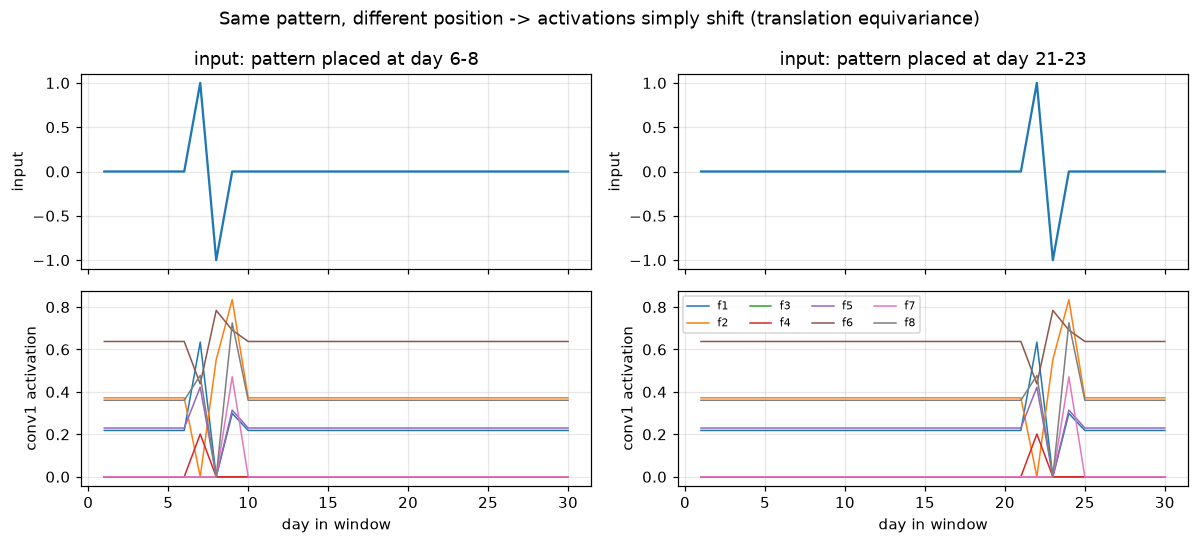

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 5), sharex=True)
for col, (x, act, pos) in enumerate([(xa, act_a, POS_A), (xb, act_b, POS_B)]):
    axes[0, col].plot(np.arange(1, LOOKBACK + 1), x[0, 0].numpy(), lw=1.5, color="C0")
    axes[0, col].set_title(f"input: pattern placed at day {pos+1}-{pos+3}")
    axes[0, col].set_ylabel("input")
    for ch in range(act.shape[0]):
        axes[1, col].plot(np.arange(1, LOOKBACK + 1), act[ch].numpy(), lw=1, label=f"f{ch+1}")
    axes[1, col].set(xlabel="day in window", ylabel="conv1 activation")
axes[1, 1].legend(ncol=4, fontsize=7)
fig.suptitle("Same pattern, different position -> activations simply shift (translation equivariance)")
fig.tight_layout()
plt.show()

**해석.** 필터는 "몇 번째 날인지"를 전혀 모른다. 오직 "**어떤 모양인지**"만 본다.
그래서 같은 모양은 어디에 있든 같은 크기로 반응한다.

이게 `low-sample-size` 문제의 해법이다. FFN이라면 "5일 위치의 급등후급락"과
"20일 위치의 급등후급락"을 각각 별도로 학습해야 하고, 그러려면 30배의 데이터가 필요하다.
CNN은 그 등가성을 **구조로 강제**하므로 데이터를 쓰지 않고 얻는다.

논문 표현으로는 이것이 economic structure를 아키텍처에 새기는 것이다. 넣은 가정은:

| 가정 | 코드 |
|---|---|
| 패턴 의미는 시점과 무관 | `nn.Conv1d` weight sharing |
| 미래를 보지 않는다 | `ConstantPad1d((filter_size-1, 0))` — 왼쪽만 패딩 |
| 패턴은 국소적 (2~3일) | `filter_size=2`, 블록 내 conv 2회 → 수용영역 3일 |
| 잔차의 절대 수준은 무의미 | `InstanceNorm1d` |
| 국소 패턴 간 관계는 전역적 | `nn.TransformerEncoderLayer` self-attention |

## §2 인과성 확인 — 정말 미래를 보지 않는가

`ConstantPad1d((1, 0), 0)`은 **왼쪽에만** 0을 붙인다. 그 결과 시점 `t`의 출력은
`t` 이하의 입력에만 의존해야 한다. 이건 look-ahead bias 방지 장치이므로 직접 검증할 가치가 있다.

미래 시점 하나를 크게 흔들었을 때 과거 시점 활성이 변하는지 본다.

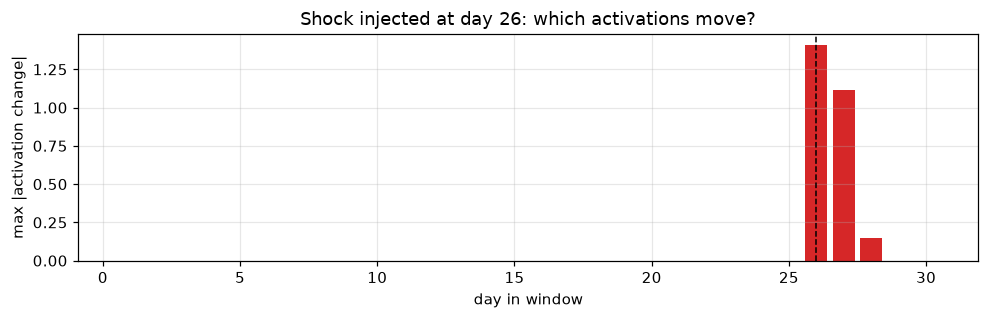

충격 이전(25일 이하) 최대 변화 : 0.000e+00
충격 이후(26일 이상) 최대 변화: 1.409e+00

과거가 미래에 오염되지 않았는가? True


In [6]:
block = model.blocks[0]
base = torch.tensor(rng.standard_normal((1, 1, LOOKBACK)), dtype=torch.float32)

perturbed = base.clone()
T_SHOCK = 25                      # 26번째 날에 큰 충격
perturbed[0, 0, T_SHOCK] += 10.0

with torch.no_grad():
    # InstanceNorm은 창 전체 통계를 쓰므로 순수 인과성 검사에서는 conv 경로만 본다
    conv_only = nn.Sequential(
        nn.ConstantPad1d((1, 0), 0), block.conv1, nn.ReLU(),
        nn.ConstantPad1d((1, 0), 0), block.conv2, nn.ReLU(),
    )
    diff = (conv_only(perturbed) - conv_only(base))[0].abs().max(dim=0).values.numpy()

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(np.arange(1, LOOKBACK + 1), diff,
       color=np.where(np.arange(LOOKBACK) < T_SHOCK, "C0", "C3"))
ax.axvline(T_SHOCK + 1, color="k", ls="--", lw=1)
ax.set(xlabel="day in window", ylabel="max |activation change|",
       title=f"Shock injected at day {T_SHOCK+1}: which activations move?")
plt.tight_layout(); plt.show()

print(f"충격 이전({T_SHOCK}일 이하) 최대 변화 : {diff[:T_SHOCK].max():.3e}")
print(f"충격 이후({T_SHOCK+1}일 이상) 최대 변화: {diff[T_SHOCK:].max():.3e}")
print("\n과거가 미래에 오염되지 않았는가?", diff[:T_SHOCK].max() < 1e-6)

**해석.** 충격 이전 시점의 활성은 정확히 0만큼 변한다. causal padding이 의도대로 동작한다.

`InstanceNorm1d`는 창 전체의 평균/분산을 쓰기 때문에 엄밀히는 창 내부에서 비인과적이다.
다만 창 자체가 `[day-30, day)`로 과거만 담고 있으므로 **거래 시점 기준 look-ahead는 아니다**.
한국 replication에서도 동일한 계약이며, 재현할 때 헷갈리기 쉬운 지점이라 명시해 둔다.

## §3 CNN이 배운 국소 기본 패턴 — Figure 15 대응

저자 노트북은 attention head 가중치 행렬 $W_qW_k^\top$를 SVD한 뒤,
그 특이벡터를 재현하는 3일짜리 입력을 `scipy.optimize.minimize`로 역산해서
"기본 패턴(basis pattern)"을 얻는다.

여기서는 더 직접적인 동등 방법을 쓴다. **각 CNN 채널의 활성을 최대화하는 3일 입력**을
경사상승으로 찾는다 (`_local_patterns`). 컴퓨터 비전의 feature visualization과 같은 기법이다.

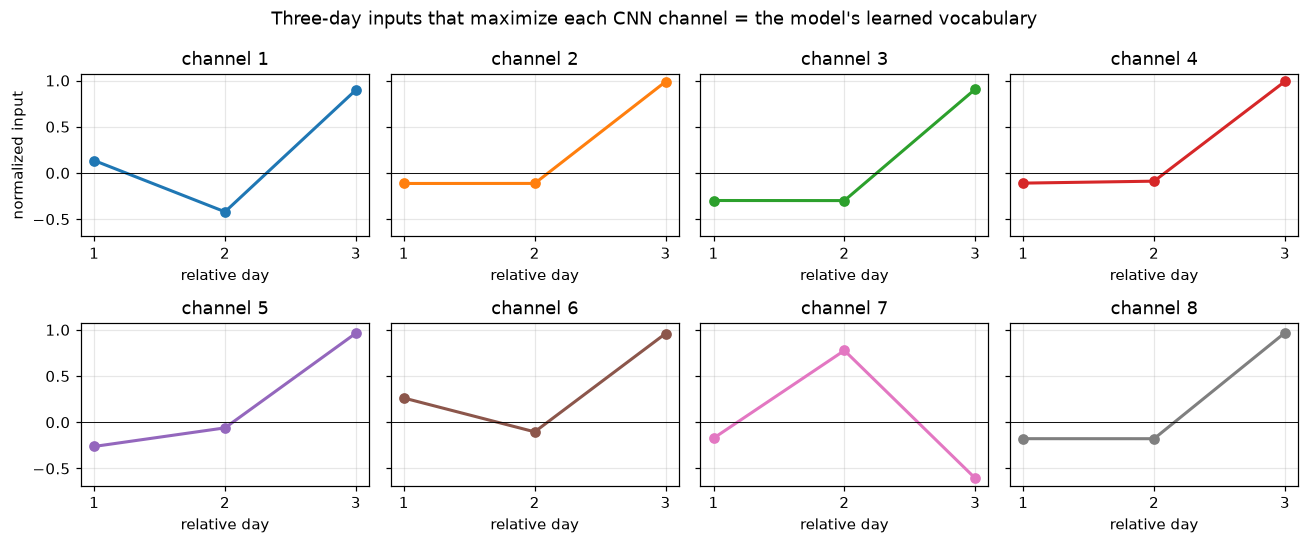

채널 1: [ 0.135 -0.42   0.897]  -> V자 반등
채널 2: [-0.114 -0.113  0.987]  -> 상승 추세
채널 3: [-0.298 -0.299  0.907]  -> V자 반등
채널 4: [-0.11  -0.089  0.99 ]  -> 상승 추세
채널 5: [-0.262 -0.061  0.963]  -> 상승 추세
채널 6: [ 0.262 -0.104  0.959]  -> V자 반등
채널 7: [-0.173  0.777 -0.606]  -> 역V자 꺾임
채널 8: [-0.178 -0.178  0.968]  -> V자 반등


In [7]:
patterns = _local_patterns(model, iterations=400)
patterns_n = patterns / (np.linalg.norm(patterns, axis=1, keepdims=True) + 1e-12)

fig, axes = plt.subplots(2, 4, figsize=(12, 5), sharey=True)
for ch, ax in enumerate(axes.ravel()):
    ax.plot([1, 2, 3], patterns_n[ch], marker="o", lw=2, color=f"C{ch}")
    ax.axhline(0, color="k", lw=0.6)
    ax.set(title=f"channel {ch+1}", xticks=[1, 2, 3], xlabel="relative day")
axes[0, 0].set_ylabel("normalized input")
fig.suptitle("Three-day inputs that maximize each CNN channel = the model's learned vocabulary")
fig.tight_layout(); plt.show()

for ch in range(patterns_n.shape[0]):
    a, b, c = patterns_n[ch]
    shape = ("상승 추세" if a < b < c else
             "하락 추세" if a > b > c else
             "V자 반등" if b < a and b < c else
             "역V자 꺾임" if b > a and b > c else "혼합")
    print(f"채널 {ch+1}: {np.round(patterns_n[ch], 3)}  -> {shape}")

**해석 방법.** 논문은 이 기본 패턴들이 "smooth trend and reversion patterns"이라고 보고한다.
위 출력에서 상승/하락 추세와 V자/역V자 반전이 함께 나오면 같은 결론이다.

이게 해석 가능성의 첫 층이다. 모델이 30일 시계열을 **8개의 3일짜리 단어**로 먼저 번역하고,
그 다음 층(Transformer)에서 단어들의 배치를 읽는다.

## §4 실제 잔차 창 하나의 내부 — Figure 17 대응

한국 종목 하나의 실제 30일 창을 골라 (1) 입력 (2) CNN 활성 8개 (3) attention 가중치를
한 화면에 그린다. 모델 안에서 그날 무슨 일이 일어났는지를 보는 것이다.

In [8]:
# OOS 구간(학습 1000일 이후)에서 관측이 가장 온전한 종목을 고른다
TRAIN_DAYS = 1000
oos_slice = selected[TRAIN_DAYS - LOOKBACK:]
ticker_idx = int(np.argmax(oos_slice.sum(axis=0)))
valid_days = [d for d in range(TRAIN_DAYS, len(panel.dates)) if selected[d - LOOKBACK, ticker_idx]]
day = valid_days[len(valid_days) // 2]

signal = torch.as_tensor(windows[day - LOOKBACK, ticker_idx][None, :], dtype=torch.float32)
with torch.no_grad():
    conv, attn = cnn_states(model, signal)
    weight = float(model(signal))

print(f"종목      : {panel.tickers[ticker_idx]}")
print(f"거래일    : {panel.dates[day].date()}   (OOS 유효 창 {len(valid_days)}개 중 중앙)")
print(f"모델 출력 : {weight:+.4f}  (정규화 전 raw allocation)")
print(f"다음날 실현 잔차: {panel.residuals[day, ticker_idx]:+.4f}")

종목      : A000080
거래일    : 2025-04-21   (OOS 유효 창 606개 중 중앙)
모델 출력 : +0.4109  (정규화 전 raw allocation)
다음날 실현 잔차: -0.0046


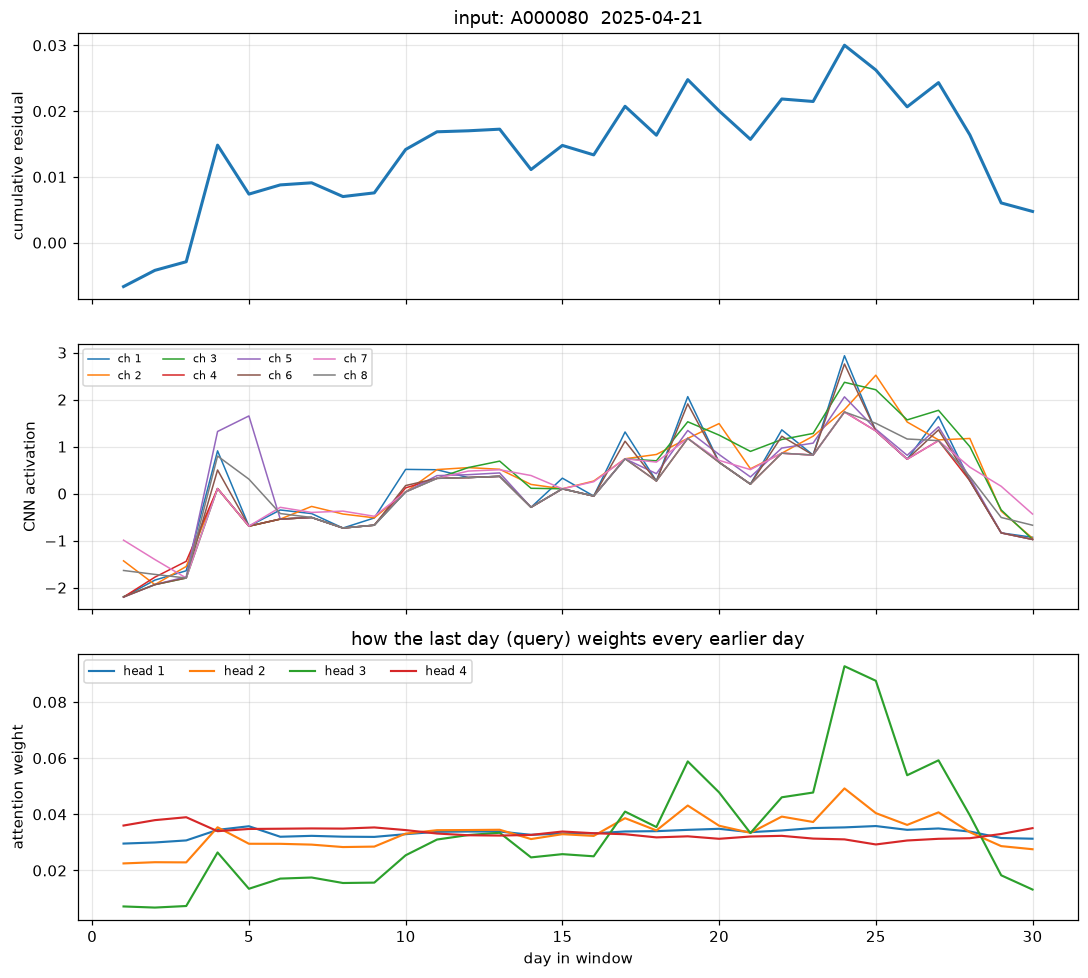

In [9]:
grid = np.arange(1, LOOKBACK + 1)
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(grid, signal.numpy().ravel(), lw=2, color="C0")
axes[0].set(ylabel="cumulative residual",
            title=f"input: {panel.tickers[ticker_idx]}  {panel.dates[day].date()}")

for ch in range(conv.shape[1]):
    axes[1].plot(grid, conv[0, ch].detach().numpy(), lw=1, label=f"ch {ch+1}")
axes[1].set(ylabel="CNN activation")
axes[1].legend(ncol=4, fontsize=7)

for head in range(attn.shape[1]):
    axes[2].plot(grid, attn[0, head, -1].detach().numpy(), lw=1.4, label=f"head {head+1}")
axes[2].set(xlabel="day in window", ylabel="attention weight",
            title="how the last day (query) weights every earlier day")
axes[2].legend(ncol=4, fontsize=8)
fig.tight_layout(); plt.show()

**읽는 법.**

- 가운데 패널: CNN 채널 8개 각각이 "자기 담당 패턴"이 나타난 시점에서 튀어오른다.
  §3에서 본 어휘가 실제 시계열의 어디에서 발견되는지를 보여준다.
- 아래 패널: **마지막 날의 판단이 30일 중 어느 날을 참조했는가**. 이게 self-attention의
  경제적 의미다. 값이 오른쪽으로 쏠려 있으면 최근 정보 위주, 평평하면 전 구간을 고르게 본다.
- head 4개가 서로 다른 모양이면 **역할 분담**을 학습한 것이다 (한 head는 최근, 다른 head는 중기 등).

## §5 사인파 probe — Figure 16 대응

저자들은 주파수를 바꾼 사인파를 모델에 먹여서 attention이 주기성에 어떻게 반응하는지 본다.
실제 데이터가 아닌 **합성 입력으로 모델을 찔러보는(probing)** 방식이다.
모델의 반응 함수를 통제된 환경에서 관찰할 수 있어 해석에 유용하다.

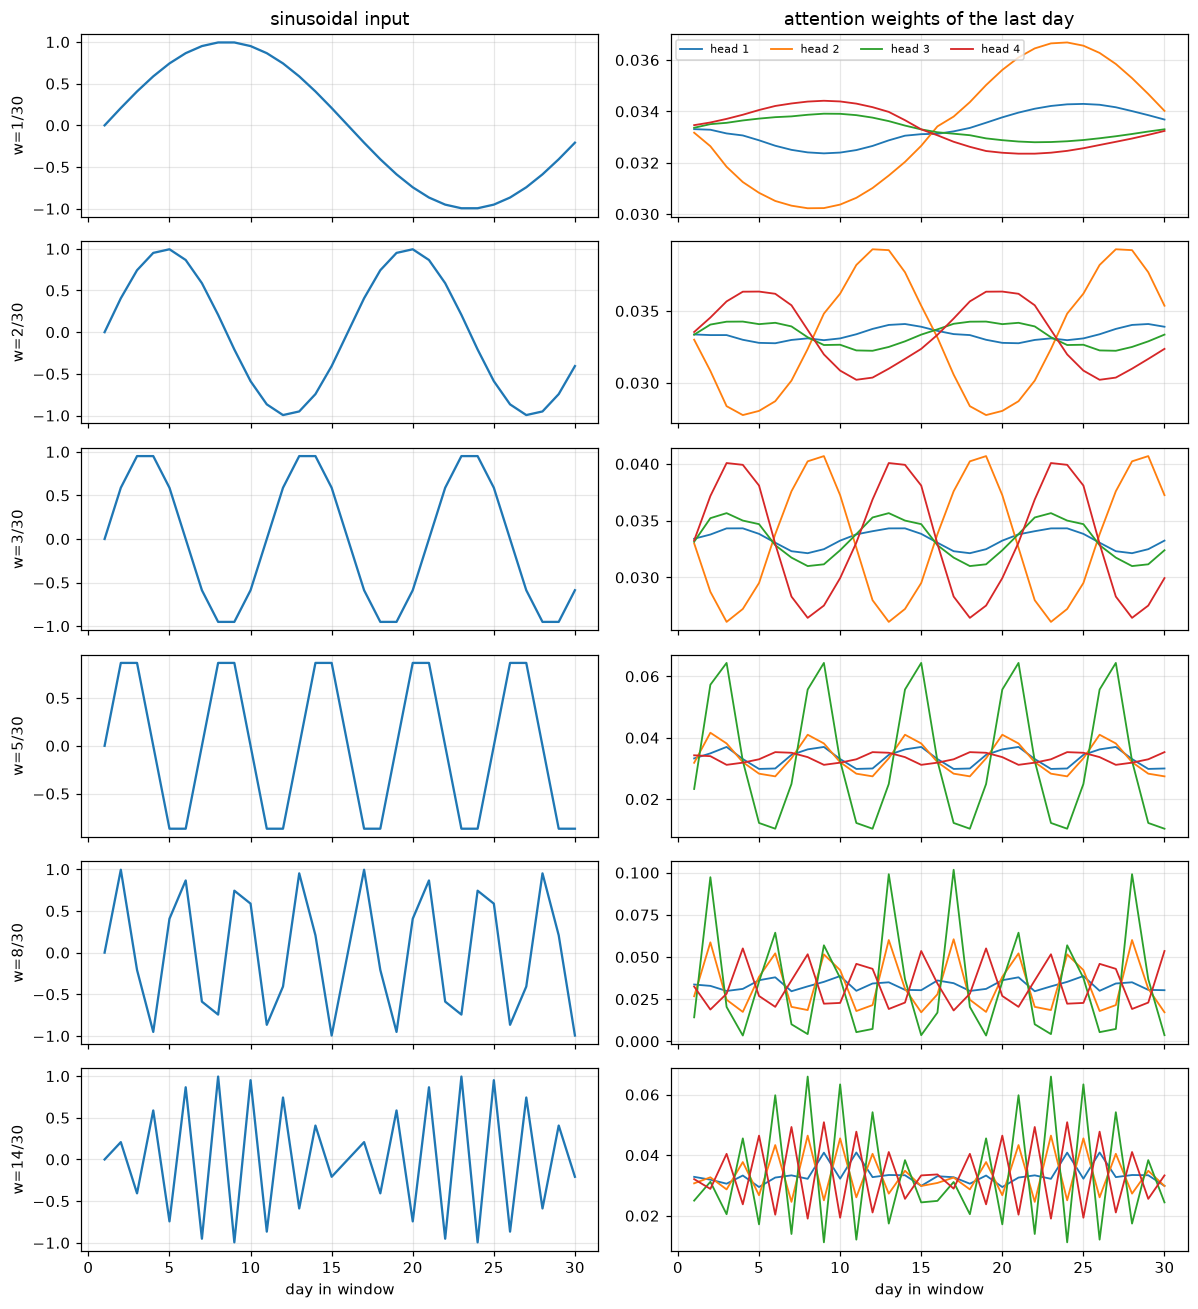

주파수별 모델 출력 (raw allocation)
  w =  1/30  (주기  30.0일) : -0.6932
  w =  2/30  (주기  15.0일) : -0.8863
  w =  3/30  (주기  10.0일) : -0.8545
  w =  5/30  (주기   6.0일) : +0.4621
  w =  8/30  (주기   3.8일) : +0.5056
  w = 14/30  (주기   2.1일) : +0.4741


In [10]:
time_grid = np.arange(LOOKBACK)
frequencies = [1, 2, 3, 5, 8, 14]

fig, axes = plt.subplots(len(frequencies), 2, figsize=(11, 2.0 * len(frequencies)), sharex=True)
outs = {}
for row, freq in enumerate(frequencies):
    sinusoid = np.sin(2 * np.pi * freq * time_grid / LOOKBACK)
    x = torch.as_tensor(sinusoid[None, :], dtype=torch.float32)
    with torch.no_grad():
        _, attention = cnn_states(model, x)
        outs[freq] = float(model(x))
    axes[row, 0].plot(time_grid + 1, sinusoid, color="C0")
    axes[row, 0].set_ylabel(f"w={freq}/30")
    for head in range(attention.shape[1]):
        axes[row, 1].plot(time_grid + 1, attention[0, head, -1].numpy(), lw=1.2,
                          label=f"head {head+1}")

axes[0, 0].set_title("sinusoidal input")
axes[0, 1].set_title("attention weights of the last day")
axes[0, 1].legend(ncol=4, fontsize=7)
axes[-1, 0].set_xlabel("day in window"); axes[-1, 1].set_xlabel("day in window")
fig.tight_layout(); plt.show()

print("주파수별 모델 출력 (raw allocation)")
for freq, value in outs.items():
    print(f"  w = {freq:>2}/30  (주기 {LOOKBACK/freq:5.1f}일) : {value:+.4f}")

**해석 포인트.**

- attention 가중치가 입력 사인파를 따라 **물결치면**, attention이 "비슷한 위상의 날들"을
  서로 묶고 있다는 뜻이다. 저자들은 이걸 근거로 attention을 학습된 주파수 필터로 해석한다.
- 출력 부호를 주파수별로 보면 모델이 **어떤 주기의 진동에 역방향으로 베팅하는지** 드러난다.
  평균회귀 전략이라면 마지막 값이 높을 때 음(매도), 낮을 때 양(매수)이 나와야 한다.
- Fourier+FFN 벤치마크는 이 주파수 분해를 **사람이 미리 고정**한 것이다. 여기서는 필요하다면
  모델이 스스로 그런 필터를 만들 수도, 안 만들 수도 있다. 논문 결과에서 CNN+Transformer가
  Fourier+FFN의 2배 성과를 낸 이유가 이 자유도다.

## §6 NAAG — 30일 중 어느 날이 중요한가 (Figure 19 대응)

**NAAG** = Normalized Average Absolute Gradient.

$$\text{NAAG}_t \;=\; \frac{\mathbb{E}\left[\left|\partial w / \partial x_t\right|\right]}{\sum_s \mathbb{E}\left[\left|\partial w / \partial x_s\right|\right]}$$

"$t$일의 입력을 아주 조금 흔들면 포지션이 얼마나 변하는가"의 평균이다. 크면 그 날이 결정에
많이 기여한다는 뜻이다. 저자 노트북은 `torch.autograd.functional.jacobian`으로 관측별
야코비안을 다 구해 평균하는데, 여기서는 배치 gradient로 같은 값을 훨씬 빠르게 얻는다.

사용한 창 개수: (8000, 30)


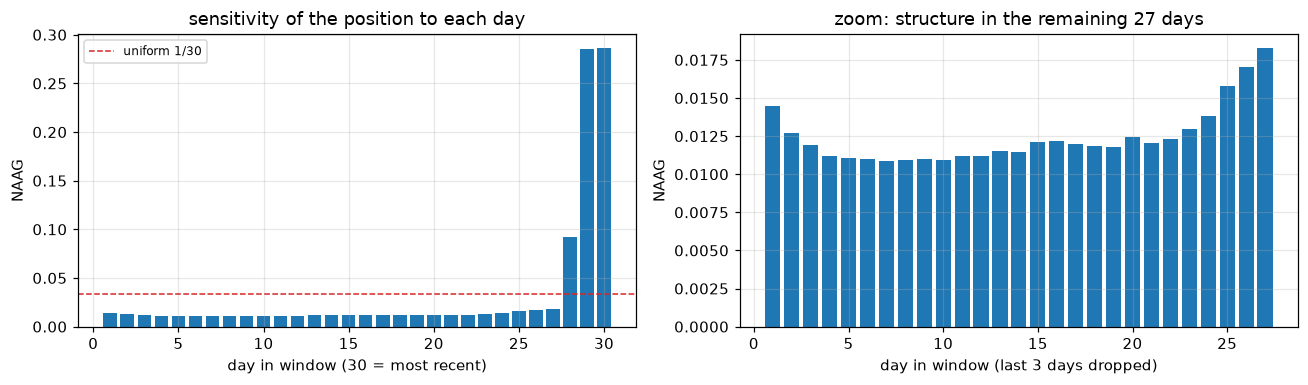

최근 3일 기여 합계 : 66.4%
최근 5일 기여 합계 : 69.9%
나머지 25일 합계   : 30.1%


In [11]:
# OOS 구간의 여러 날 x 여러 종목 창을 모아 하나의 배치로 만든다
def collect_windows(day_range, max_rows=8000, seed=SEED):
    rows = [windows[d - LOOKBACK, selected[d - LOOKBACK]] for d in day_range]
    stacked = np.concatenate([r for r in rows if len(r)], axis=0)
    if len(stacked) > max_rows:
        pick = np.random.default_rng(seed).choice(len(stacked), max_rows, replace=False)
        stacked = stacked[pick]
    return stacked

OOS_DAYS = range(TRAIN_DAYS, min(TRAIN_DAYS + 125, len(panel.dates)))
batch = collect_windows(OOS_DAYS)
print("사용한 창 개수:", batch.shape)

X = torch.as_tensor(batch, dtype=torch.float32).requires_grad_(True)
out = model(X)
grad, = torch.autograd.grad(out.sum(), X)
naag = grad.abs().mean(0).detach().numpy()
naag = naag / naag.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].bar(np.arange(1, LOOKBACK + 1), naag, color="C0")
axes[0].axhline(1 / LOOKBACK, color="C3", ls="--", lw=1, label="uniform 1/30")
axes[0].set(xlabel="day in window (30 = most recent)", ylabel="NAAG",
            title="sensitivity of the position to each day")
axes[0].legend(fontsize=8)

axes[1].bar(np.arange(1, LOOKBACK - 2), naag[:LOOKBACK - 3], color="C0")
axes[1].set(xlabel="day in window (last 3 days dropped)", ylabel="NAAG",
            title="zoom: structure in the remaining 27 days")
fig.tight_layout(); plt.show()

print(f"최근 3일 기여 합계 : {naag[-3:].sum():.1%}")
print(f"최근 5일 기여 합계 : {naag[-5:].sum():.1%}")
print(f"나머지 25일 합계   : {naag[:-5].sum():.1%}")

**해석.** 최근 며칠의 기여가 압도적이라면 모델의 판단은 사실상 단기 반전에 걸려 있다는 뜻이다.
다만 오른쪽 확대 그림에서 나머지 날들이 **평평하지 않고 구조를 가지면**, 그 부분이
단순 최근 수익률로는 얻을 수 없는 추가 정보이고 CNN+Transformer가 벌어들이는 초과 성과의 원천이다.

논문은 미국 표본에서 "지난 30 거래일이 관련 정보를 포착한다"고 보고한다.
한국 표본에서 최근 며칠 쏠림이 더 강하게 나온다면, 그건 오류가 아니라
**표본이 다르다는 관측 결과**다. Table 5–6의 lookback 60일 비교와 함께 해석해야 한다.

### 신호별 기여도

최종 배분은 Transformer 출력 8차원(= 신호)의 선형결합이다. 신호별 중요도도 같은 방식으로 잰다.

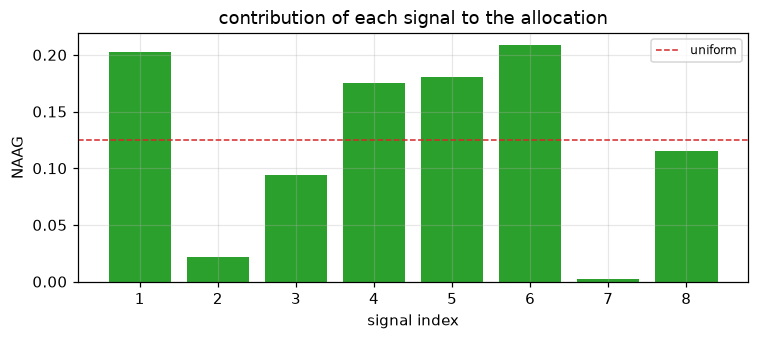

기여 상위 신호: #6(20.9%), #1(20.2%), #5(18.1%), #4(17.6%)
상위 3개 신호의 누적 기여: 59.2%


In [12]:
# 마지막 선형층 직전의 8차원 표현에 대한 민감도
feats = {}
handle = model.linear.register_forward_pre_hook(lambda m, inp: feats.__setitem__("h", inp[0]))
X2 = torch.as_tensor(batch, dtype=torch.float32)
_ = model(X2)
handle.remove()

h = feats["h"].detach().requires_grad_(True)
y = model.linear(h).squeeze(-1)
gh, = torch.autograd.grad(y.sum(), h)
signal_naag = gh.abs().mean(0).numpy()
signal_naag = signal_naag / signal_naag.sum()

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(np.arange(1, len(signal_naag) + 1), signal_naag, color="C2")
ax.axhline(1 / len(signal_naag), color="C3", ls="--", lw=1, label="uniform")
ax.set(xlabel="signal index", ylabel="NAAG", title="contribution of each signal to the allocation")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

order = np.argsort(-signal_naag)
print("기여 상위 신호:", ", ".join(f"#{i+1}({signal_naag[i]:.1%})" for i in order[:4]))
print(f"상위 3개 신호의 누적 기여: {signal_naag[order[:3]].sum():.1%}")

소수 신호에 기여가 몰려 있으면 8차원 중 실제로 쓰이는 건 몇 개뿐이라는 뜻이고,
모델을 더 줄일 여지가 있다는 신호다. 고르게 퍼져 있으면 8개 폭이 정당화된다.

## §7 상승/하락 비대칭성 — Introduction 주장 검증

논문 Introduction의 주장:

> "the direction of policies is **asymmetric**. The model reacts **quickly on downturn**
> movements, but **more cautiously on uptrends**. ... the global dependency patterns which are
> the most active in downturn movements focus only on the **most recent 10 days**, while those
> for upward movements focus on the **first 20 days** in a 30-day window."

이걸 한국 모델에서 직접 검증한다. 최근 5일 잔차 변화의 상하위 20%를 각각 "상승"/"하락"으로
나눈 뒤, 두 집단의 attention 분포와 배분 가중치를 비교한다.

상승 표본 1,600개 / 하락 표본 1,600개


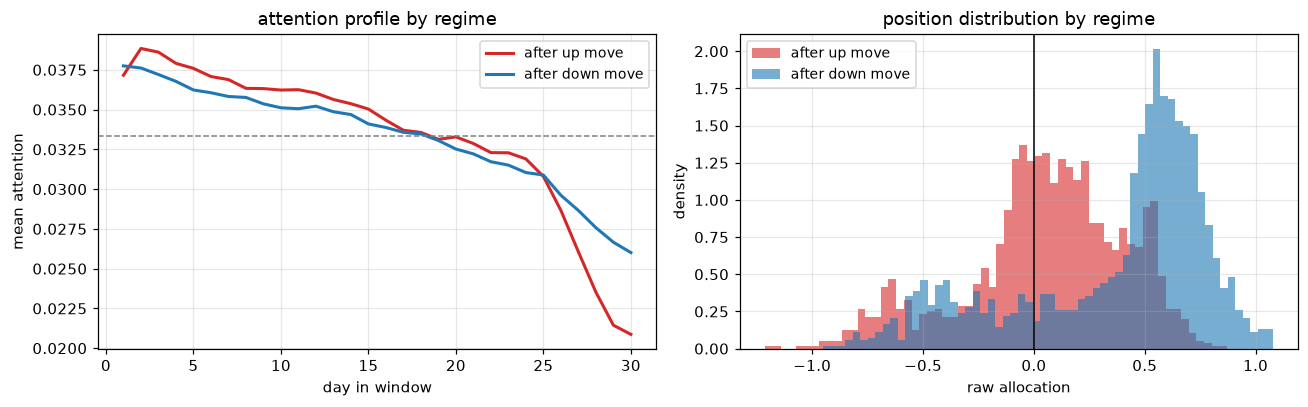

attention 무게중심   상승: 14.40일   하락: 14.71일
최근 10일 attention  상승: 28.1%   하락: 29.6%
평균 포지션          상승: +0.0542   하락: +0.3619
포지션 표준편차      상승: 0.3618   하락: 0.4373


In [13]:
Xb = torch.as_tensor(batch, dtype=torch.float32)
with torch.no_grad():
    _, attn_all = cnn_states(model, Xb)
    w_all = model(Xb).numpy()

attn_last = attn_all[:, :, -1, :].mean(dim=1).numpy()   # head 평균 -> (B, 30)

recent_move = batch[:, -1] - batch[:, -6]               # 최근 5일 누적 잔차 변화
up = recent_move > np.quantile(recent_move, 0.80)
down = recent_move < np.quantile(recent_move, 0.20)
print(f"상승 표본 {up.sum():,}개 / 하락 표본 {down.sum():,}개")

grid = np.arange(1, LOOKBACK + 1)
a_up, a_dn = attn_last[up].mean(0), attn_last[down].mean(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(grid, a_up, lw=2, label="after up move", color="C3")
axes[0].plot(grid, a_dn, lw=2, label="after down move", color="C0")
axes[0].axhline(1 / LOOKBACK, color="gray", ls="--", lw=1)
axes[0].set(xlabel="day in window", ylabel="mean attention",
            title="attention profile by regime")
axes[0].legend(fontsize=9)

axes[1].hist(w_all[up], bins=60, alpha=0.6, label="after up move", color="C3", density=True)
axes[1].hist(w_all[down], bins=60, alpha=0.6, label="after down move", color="C0", density=True)
axes[1].axvline(0, color="k", lw=1)
axes[1].set(xlabel="raw allocation", ylabel="density", title="position distribution by regime")
axes[1].legend(fontsize=9)
fig.tight_layout(); plt.show()

com = lambda a: float((a * grid).sum() / a.sum())
print(f"attention 무게중심   상승: {com(a_up):.2f}일   하락: {com(a_dn):.2f}일")
print(f"최근 10일 attention  상승: {a_up[-10:].sum():.1%}   하락: {a_dn[-10:].sum():.1%}")
print(f"평균 포지션          상승: {w_all[up].mean():+.4f}   하락: {w_all[down].mean():+.4f}")
print(f"포지션 표준편차      상승: {w_all[up].std():.4f}   하락: {w_all[down].std():.4f}")

**두 종류의 비대칭을 구분해서 봐야 한다.**

1. **참조 구간의 비대칭** (attention 무게중심) — 논문이 미국 표본에서 보고한 "하락은 최근 10일,
   상승은 앞쪽 20일". 두 값의 차이가 작으면 한국 모델에서는 이 형태로 재현되지 않은 것이다.
2. **반응 크기의 비대칭** (평균 포지션) — 하락 후 평균 포지션이 상승 후보다 훨씬 크면,
   모델이 **하락에 공격적으로 매수하고 상승에는 소극적**이라는 뜻이다. 이건 논문이 말한
   "reacts quickly on downturn, more cautiously on uptrends"와 방향이 같다.

한국 데이터에서 2번은 뚜렷하고 1번은 약하게 나올 수 있다. 그 경우 결론은
"비대칭성은 재현되나, 그 비대칭이 attention의 참조 구간이 아니라 배분 함수에서 나온다"이며,
이건 replication에서 그대로 보고할 가치가 있는 차이다.

## §8 잔차 가격 대 배분 가중치 — Figure 14 대응

마지막으로 가장 직관적인 그림이다. 한 종목의 **잔차 가격 경로**와 모델이 매일 내놓은
**포지션**을 겹쳐 그린다. 모델이 언제 사고 언제 파는지를 눈으로 확인하는 단계다.

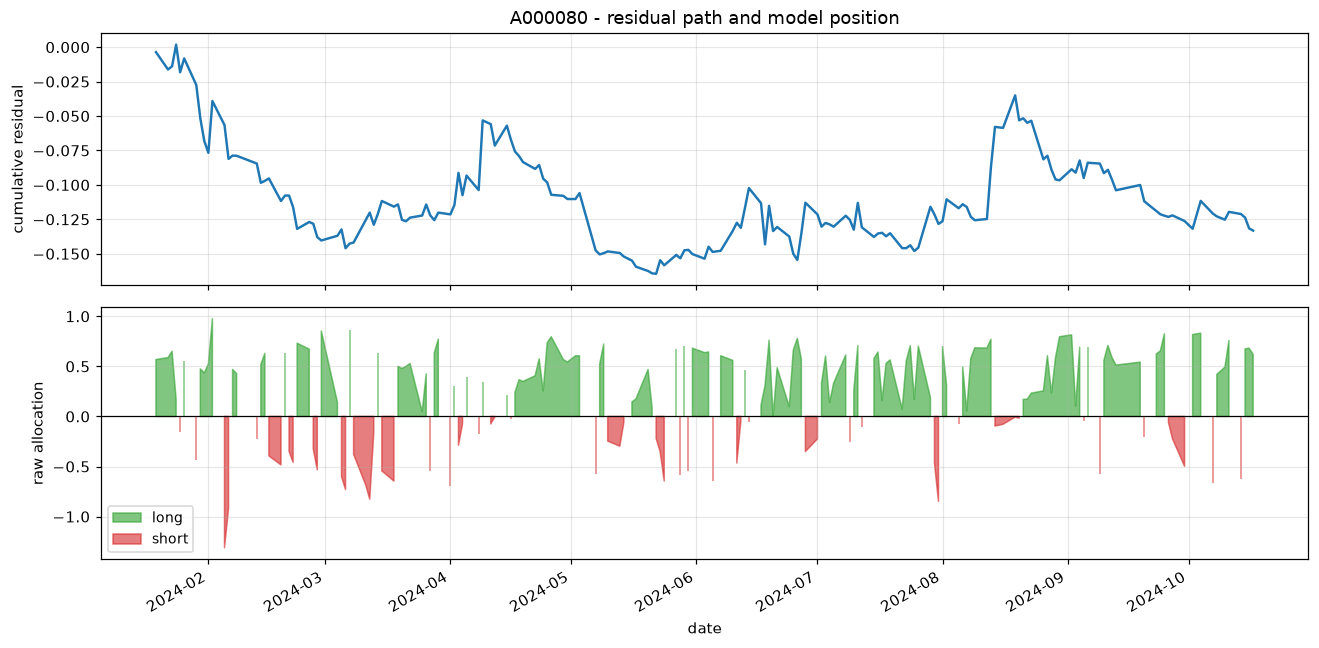

corr(포지션, 최근 5일 잔차 변화) = -0.266
corr(포지션, 다음날 실현 잔차)   = +0.236


In [14]:
N_DAYS = 180
plot_days = [d for d in valid_days if d < TRAIN_DAYS + N_DAYS][:N_DAYS]

seq = np.stack([windows[d - LOOKBACK, ticker_idx] for d in plot_days])
with torch.no_grad():
    raw_w = model(torch.as_tensor(seq, dtype=torch.float32)).numpy()

res_price = np.cumsum(panel.residuals[plot_days, ticker_idx])
dates = panel.dates[plot_days]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(dates, res_price, lw=1.6, color="C0")
axes[0].set(ylabel="cumulative residual",
            title=f"{panel.tickers[ticker_idx]} - residual path and model position")

axes[1].axhline(0, color="k", lw=0.8)
axes[1].fill_between(dates, 0, raw_w, where=raw_w >= 0, color="C2", alpha=0.6, label="long")
axes[1].fill_between(dates, 0, raw_w, where=raw_w < 0, color="C3", alpha=0.6, label="short")
axes[1].set(ylabel="raw allocation", xlabel="date")
axes[1].legend(fontsize=9)
fig.autofmt_xdate()
fig.tight_layout(); plt.show()

# 평균회귀 전략이라면 포지션과 최근 잔차 움직임이 음의 상관을 가져야 한다
recent5 = seq[:, -1] - seq[:, -6]
print(f"corr(포지션, 최근 5일 잔차 변화) = {np.corrcoef(raw_w, recent5)[0, 1]:+.3f}")
print(f"corr(포지션, 다음날 실현 잔차)   = "
      f"{np.corrcoef(raw_w, panel.residuals[plot_days, ticker_idx])[0, 1]:+.3f}")

**읽는 법.**

- 첫 번째 상관계수가 **음수**면 평균회귀 전략이 맞다. 최근 오른 잔차는 팔고, 내린 잔차는 산다.
- 두 번째 상관계수가 **양수**면 그 판단이 실제로 다음날 수익으로 이어졌다는 뜻이다.
  종목 하나·기간 일부의 표본이라 값 자체는 작고 불안정하니, **부호와 방향**만 본다.
  성과의 공식 수치는 `outputs/strategies/.../daily_performance.csv`와
  `simulation_audit.json`에 있다.

In [15]:
import json
audit = json.loads((CHECKPOINT.parent.parent / "simulation_audit.json").read_text("utf-8"))
print("이 체크포인트가 속한 전략의 공식 성과 (한국 PCA5, OOS)")
for key in ["factor_model", "model", "objective", "oos_start", "oos_end",
            "annual_return", "annual_volatility", "sharpe",
            "mean_daily_turnover", "mean_short_proportion"]:
    print(f"  {key:<22}: {audit[key]}")
print("\n데이터 한계:")
for line in audit["data_limitations"]:
    print("  -", line)

이 체크포인트가 속한 전략의 공식 성과 (한국 PCA5, OOS)
  factor_model          : PCA5
  model                 : cnn_transformer
  objective             : sharpe
  oos_start             : 2024-01-19
  oos_end               : 2026-07-20
  annual_return         : 0.16753621511293879
  annual_volatility     : 0.04039285671164147
  sharpe                : 4.147668357112515
  mean_daily_turnover   : 1.2143595258985023
  mean_short_proportion : 0.5021812294674391

데이터 한계:
  - cash-dividend-excluding adjusted price returns, not total returns
  - exact 240-month IPCA branch is history-blocked
  - Korean universe is smaller than the U.S. CRSP universe


## 정리 — 무엇을 확인했나

| 절 | 확인한 것 | 원 논문 주장과의 관계 |
|---|---|---|
| §1 | 파라미터 769개 vs FFN 6,209개, 평행이동 등변성 성립 | weight sharing이 low-sample-size 문제의 해법 |
| §2 | causal padding으로 미래 정보가 새지 않음 | look-ahead bias 방지 장치 |
| §3 | CNN 채널 8개 = 추세/반전 3일 어휘 | Fig 15 "smooth trend and reversion patterns" |
| §4 | 한 창의 CNN 활성 + attention 분포 | Fig 17 |
| §5 | 사인파 probe로 attention 주파수 반응 | Fig 16, Fourier 벤치마크와의 대비 |
| §6 | 일자별·신호별 기여도(NAAG) | Fig 19, "지난 30일이 관련 정보" |
| §7 | 상승/하락 비대칭 | Introduction의 asymmetry 주장 |
| §8 | 잔차 경로 대 포지션 | Fig 14 |

### 저자 공식 노트북과의 차이

| 항목 | 저자 노트북 | 이 노트북 |
|---|---|---|
| 잔차 | 미국 IPCA5, 1998–2016 | 한국 PCA5, 2020–2026 |
| 체크포인트 | 저자 학습 모델 | 로컬 학습 `subperiod_00.pt` |
| Fig 15 방법 | attention 행렬 SVD + `scipy.optimize` 역산 | CNN 채널 활성 최대화 경사상승 |
| Fig 19 방법 | 관측별 `functional.jacobian` 평균 | 배치 gradient (수학적으로 동일, 훨씬 빠름) |
| 실행 요건 | GPU, 수백 GB 잔차 | CPU, 저장소 내 파일만 |

### 다음에 해볼 것

- `subperiod_00` ~ `subperiod_04`를 모두 불러 **패턴이 재학습 구간마다 안정적인지** 비교 (Fig 18 성격)
- `pca5` 대신 `ff5_cnn_transformer_...` 체크포인트로 바꿔 **factor model이 학습된 필터를 바꾸는지** 확인
  (논문 결론: factor 선택은 성과에 부차적 → 필터도 비슷해야 함)
- `outputs/strategies/*_fourier_ffn_*`, `*_direct_ffn_*`와 §6 NAAG를 비교해
  **시계열 구조가 없는 모델은 어느 날을 보는지** 대조